In [1]:
import pandas as pd
import numpy as np

In [2]:
# df = pd.read_csv('sales_data.csv')
# df = pd.read_csv('.././sales_data.csv')
df = pd.read_csv('../data/sales_data.csv')

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [6]:
print(df['Date'].max(), df['Date'].min())

2024-01-30 2022-01-01


In [7]:
df['Weather Condition'].unique()

<StringArray>
['Snowy', 'Cloudy', 'Sunny', 'Rainy']
Length: 4, dtype: str

In [8]:
df['Epidemic'].unique()

array([0, 1])

In [9]:
df['Category'].unique()

<StringArray>
['Electronics', 'Clothing', 'Groceries', 'Toys', 'Furniture']
Length: 5, dtype: str

In [10]:
df['Region'].unique()

<StringArray>
['North', 'South', 'East', 'West']
Length: 4, dtype: str

In [11]:
## Checking outliers of Units Sold

# 1. Calculate Q1 and Q3
Q1 = df['Units Sold'].quantile(0.25)
Q3 = df['Units Sold'].quantile(0.75)

IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
outliers = df[(df['Units Sold'] < lower_bound) | (df['Units Sold'] > upper_bound)].copy()

# Inspect Outliers found
print(f"Total Outliers found: {len(outliers)}")
print("Outliers using IQR: ", outliers.head())

Total Outliers found: 1411
Outliers using IQR:             Date Store ID Product ID     Category Region  Inventory Level  \
368  2022-01-04     S004      P0009     Clothing   West              299   
428  2022-01-05     S002      P0009    Groceries  South              279   
430  2022-01-05     S002      P0011    Groceries  South              559   
450  2022-01-05     S003      P0011  Electronics   East              503   
469  2022-01-05     S004      P0010    Groceries   West              597   

     Units Sold  Units Ordered   Price  Discount Weather Condition  Promotion  \
368         201              0  143.79        15            Cloudy          1   
428         243            521   86.08        10             Snowy          1   
430         206            568  120.94        10             Snowy          1   
450         243              0  130.31        25             Sunny          1   
469         218            784   29.29        20            Cloudy          1   

     Com

In [12]:
## Outlier using Z-score method
from scipy import stats

#Calculate absolute z-score
z_score = np.abs(stats.zscore(df['Units Sold']))

# Filter rows where z-score is greater than 3
z_outliers = df[z_score > 3]
print("Outliers using z_score", z_outliers)

Outliers using z_score              Date Store ID Product ID     Category Region  Inventory Level  \
428    2022-01-05     S002      P0009    Groceries  South              279   
450    2022-01-05     S003      P0011  Electronics   East              503   
653    2022-01-07     S003      P0014    Groceries   East              821   
746    2022-01-08     S003      P0007    Groceries   East              791   
859    2022-01-09     S003      P0020     Clothing   East              390   
...           ...      ...        ...          ...    ...              ...   
75402  2024-01-25     S001      P0003     Clothing  North              343   
75472  2024-01-25     S004      P0013    Groceries   West              319   
75717  2024-01-28     S001      P0018    Groceries  North              248   
75765  2024-01-28     S004      P0006    Groceries   West              518   
75802  2024-01-29     S001      P0003     Clothing  North              656   

       Units Sold  Units Ordered   Price

In [13]:
print(z_outliers[z_outliers['Units Ordered']==0])

             Date Store ID Product ID     Category Region  Inventory Level  \
450    2022-01-05     S003      P0011  Electronics   East              503   
653    2022-01-07     S003      P0014    Groceries   East              821   
859    2022-01-09     S003      P0020     Clothing   East              390   
1594   2022-01-16     S005      P0015    Groceries  North              542   
1602   2022-01-17     S001      P0003     Clothing  North              989   
...           ...      ...        ...          ...    ...              ...   
74992  2024-01-20     S005      P0013    Groceries  North              857   
75402  2024-01-25     S001      P0003     Clothing  North              343   
75472  2024-01-25     S004      P0013    Groceries   West              319   
75765  2024-01-28     S004      P0006    Groceries   West              518   
75802  2024-01-29     S001      P0003     Clothing  North              656   

       Units Sold  Units Ordered   Price  Discount Weather Cond

In [14]:
# import matplotlib.pyplot as plt

# df.boxplot(column=['Units Sold'])
# plt.title('Box Plot of Unit Sold')
# plt.show()

In [15]:
# df.plot.scatter(x='Date', y='Units Sold')
# plt.title('Scatter plot of units sold')
# plt.show()

In [16]:
df['Demand'].describe()

count    76000.000000
mean       104.317158
std         46.964801
min          4.000000
25%         71.000000
50%        100.000000
75%        133.000000
max        430.000000
Name: Demand, dtype: float64

In [17]:
df['Demand'].value_counts().sort_index()

Demand
4      64
5      18
6      21
7      20
8      34
       ..
370     1
372     1
373     1
378     1
430     1
Name: count, Length: 340, dtype: int64

In [18]:
df[["Demand", "Units Sold", "Units Ordered", "Inventory Level"]].corr()

,Demand,Units Sold,Units Ordered,Inventory Level
Demand,1.000000,0.833421,0.511963,0.126618
Units Sold,0.833421,1.000000,0.433943,0.234590
Units Ordered,0.511963,0.433943,1.000000,-0.034698
Inventory Level,0.126618,0.234590,-0.034698,1.000000


In [19]:
df[["Demand", "Units Sold"]].head(20)

,Demand,Units Sold
0,115,102
1,229,117
2,157,114
3,52,45
4,59,65
5,55,60
6,94,81
7,61,42
8,129,88
9,69,70


In [20]:
(df["Demand"] == df["Units Sold"]).mean()

np.float64(0.020526315789473684)

Understanding the grain of dataset

In [21]:
# checking -> one store + one Product + one day

df.groupby(["Date", "Store ID", "Product ID"]).size().value_counts()


1    76000
Name: count, dtype: int64

In [22]:
df["Date"].nunique()

760

In [23]:
df["Store ID"].nunique()

5

In [24]:
df["Product ID"].nunique()

20

In [25]:
df.groupby(["Store ID", "Product ID"]).size().describe()

count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
dtype: float64

Date Conversion <br>
str -> date

In [26]:
df["Date"] = pd.to_datetime(df["Date"])

In [27]:
df["Date"].min(), df["Date"].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-30 00:00:00'))

In [28]:
df["Date"].sort_values().diff().value_counts()

Date
0 days    75240
1 days      759
Name: count, dtype: int64

In [29]:
df["Date"].dt.dayofweek.value_counts().sort_index()

Date
0    10900
1    10900
2    10800
3    10800
4    10800
5    10900
6    10900
Name: count, dtype: int64

In [30]:
df["Date"].dt.month.value_counts().sort_index()

Date
1     9200
2     5600
3     6200
4     6000
5     6200
6     6000
7     6200
8     6200
9     6000
10    6200
11    6000
12    6200
Name: count, dtype: int64

Investigating 0 values


In [31]:
(df["Units Sold"] == 0).mean()

np.float64(0.0053421052631578946)

In [32]:
df.groupby("Category")["Units Sold"].apply(
    lambda x: (x == 0).mean()
)

Category
Clothing       0.004523
Electronics    0.005044
Furniture      0.003363
Groceries      0.006842
Toys           0.004793
Name: Units Sold, dtype: float64

In [33]:
df.groupby("Store ID")["Units Sold"].apply(
    lambda x: (x == 0).mean()
).sort_values(ascending=False)

Store ID
S002    0.006118
S005    0.005987
S003    0.005592
S004    0.005132
S001    0.003882
Name: Units Sold, dtype: float64

Investigate Other numerical cols

In [34]:
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Demand"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Inventory Level,76000.0,301.062842,226.510161,0.00,136.0000,227.0,408.0000,2267.00
Units Sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00
Units Ordered,76000.0,89.090645,162.404627,0.00,0.0000,0.0,121.0000,1616.00
Price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03
Discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00
Promotion,76000.0,0.328947,0.469834,0.00,0.0000,0.0,1.0000,1.00
Competitor Pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22
Epidemic,76000.0,0.200000,0.400003,0.00,0.0000,0.0,0.0000,1.00
Demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00


Investigate categorical variables

In [35]:
categorical_cols = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 Store ID
Store ID
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64

 Product ID
Product ID
P0001    3800
P0002    3800
P0003    3800
P0004    3800
P0005    3800
P0006    3800
P0007    3800
P0008    3800
P0009    3800
P0010    3800
P0011    3800
P0012    3800
P0013    3800
P0014    3800
P0015    3800
P0016    3800
P0017    3800
P0018    3800
P0019    3800
P0020    3800
Name: count, dtype: int64

 Category
Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64

 Region
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64

 Weather Condition
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64

 Seasonality
Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64


In [36]:
df[categorical_cols].nunique()

Store ID              5
Product ID           20
Category              5
Region                4
Weather Condition     4
Seasonality           4
dtype: int64

Preprocessing

In [37]:
# What could influence demand?
# Hypothesis: Higher price may reduce demand

df.groupby(pd.qcut(df["Price"], 10))["Demand"].mean().sort_values()

Price
(4.739, 19.859]        96.634079
(121.921, 228.03]      97.666184
(103.152, 121.921]     99.780526
(19.859, 27.248]      103.702105
(89.14, 103.152]      103.882732
(53.266, 64.5]        106.089582
(76.14, 89.14]        106.366544
(37.86, 53.266]       107.174852
(27.248, 37.86]       108.555556
(64.5, 76.14]         113.316101
Name: Demand, dtype: float64

In [38]:
# Hypothesis: Higher discount may increase demand
df.groupby("Discount")["Demand"].mean()

Discount
0      94.748861
5      94.941896
10    102.767834
15    123.575981
20    124.065256
25    122.967374
Name: Demand, dtype: float64

In [39]:
# Hypothesis: Promotions increase demand
df.groupby("Promotion")["Demand"].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

In [40]:
# Weather
df.groupby("Weather Condition")["Demand"].agg(
    ["mean", "median", "std", "count"]
)

,mean,median,std,count
Weather Condition,,,,
Cloudy,105.404064,102.0,46.645370,24360
Rainy,95.106743,92.0,42.642277,17500
Snowy,94.045789,91.0,39.520209,11160
Sunny,115.167189,111.0,51.092824,22980


In [41]:
# Seasonality
df.groupby("Seasonality")["Demand"].agg(
    ["mean", "median", "std", "count"]
)

,mean,median,std,count
Seasonality,,,,
Autumn,103.422967,100.0,41.974885,18200
Spring,97.703098,95.0,46.038644,18400
Summer,112.855380,107.0,51.930652,18400
Winter,103.406190,100.0,46.174414,21000


In [42]:
# Epidemic
df.groupby("Epidemic")["Demand"].agg(
    ["mean", "median", "count"]
)

,mean,median,count
Epidemic,,,
0,112.856743,108.0,60800
1,70.158816,64.0,15200


Investigate temporal patterns

In [43]:
daily_demand = (
    df.groupby("Date")["Demand"]
    .sum()
    .sort_index()
)

<Axes: xlabel='Date'>

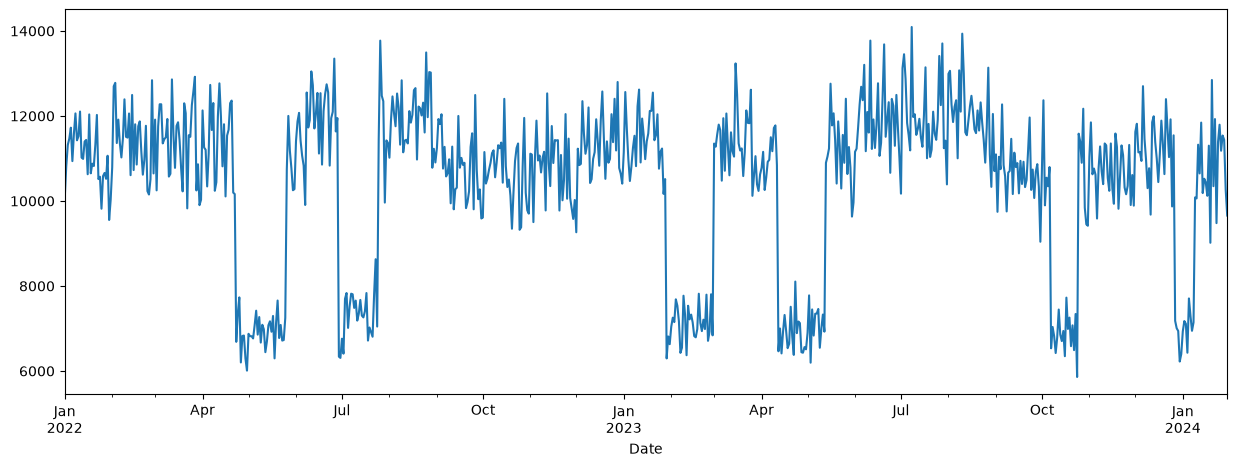

In [44]:
daily_demand.plot(figsize=(15, 5))

In [45]:
## weekly behaviour
df["day_of_week"] = df["Date"].dt.day_name()

df.groupby("day_of_week")["Demand"].mean()

day_of_week
Friday       104.394444
Monday       103.423303
Saturday     104.484037
Sunday       104.662294
Thursday     104.408333
Tuesday      103.665229
Wednesday    105.192037
Name: Demand, dtype: float64

In [46]:
df["month"] = df["Date"].dt.month

df.groupby("month")["Demand"].mean()

month
1     106.040000
2      92.882500
3     113.613871
4      92.816667
5      86.521129
6     117.346000
7     101.561613
8     119.803387
9     107.431500
10     95.557258
11    107.542333
12    109.003226
Name: Demand, dtype: float64

In [47]:
# # # Important check - Is actually
# # Inventory = 0
# # Units Sold = 0

# # There could have been:
# # Demand = 100
# # Inventory = 0
# # Units Sold = 0

# because the store stocked out.

# That means observed sales are not necessarily the same as true demand.

# This is a classic issue:

# True Demand
#      ↓
# Inventory constraint
#      ↓
# Observed Units Sold

In [48]:
df.groupby("Inventory Level")["Units Sold"].mean()

Inventory Level
0         0.0
1         1.0
2         2.0
3         3.0
4         4.0
        ...  
1977    133.0
2007     75.0
2059     85.0
2195    136.0
2267     72.0
Name: Units Sold, Length: 1426, dtype: float64

In [49]:
df[df["Inventory Level"] == 0][
    ["Units Sold", "Units Ordered", "Demand"]
].describe()

,Units Sold,Units Ordered,Demand
count,406.0,406.000000,406.000000
mean,0.0,76.884236,115.403941
std,0.0,177.685181,47.932405
min,0.0,0.000000,6.000000
25%,0.0,0.000000,82.000000
50%,0.0,0.000000,110.000000
75%,0.0,0.000000,145.000000
max,0.0,1016.000000,316.000000


In [50]:
df[['Demand', 'Promotion', 'Competitor Pricing', 'Discount']].corr()

,Demand,Promotion,Competitor Pricing,Discount
Demand,1.000000,0.282537,-0.023036,0.224723
Promotion,0.282537,1.000000,-0.041385,0.784039
Competitor Pricing,-0.023036,-0.041385,1.000000,-0.092066
Discount,0.224723,0.784039,-0.092066,1.000000


<h1>Zero sales observation</h1>

In [51]:
zero_sales = (df["Units Sold"] == 0).sum()
total_rows = len(df)

print("Zero-sales observations: ", zero_sales)
print("Percentage:", round(zero_sales/total_rows * 100, 2), "%")

Zero-sales observations:  406
Percentage: 0.53 %


In [52]:
# Compare zero sales with demand
zero_sales_df = df[df["Units Sold"] == 0]

zero_sales_df["Demand"].describe()

count    406.000000
mean     115.403941
std       47.932405
min        6.000000
25%       82.000000
50%      110.000000
75%      145.000000
max      316.000000
Name: Demand, dtype: float64

In [53]:
zero_sales_df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,day_of_week,month
120,2022-01-02,S002,P0001,Groceries,South,0,0,350,86.71,10,Cloudy,0,85.00,Winter,0,137,Sunday,1
128,2022-01-02,S002,P0009,Groceries,South,0,0,263,74.78,0,Cloudy,0,83.48,Winter,0,158,Sunday,1
135,2022-01-02,S002,P0016,Clothing,South,0,0,260,107.38,0,Cloudy,0,114.77,Winter,0,159,Sunday,1
152,2022-01-02,S003,P0013,Groceries,East,0,0,0,69.14,0,Cloudy,0,72.85,Winter,0,83,Sunday,1
181,2022-01-02,S005,P0002,Electronics,North,0,0,0,40.81,10,Snowy,0,38.43,Winter,0,106,Sunday,1


In [54]:
# Units Sold = 0
#         |
#         ├── Demand also ~0
#         │      → probably genuinely no sales
#         │
#         └── Demand > 0
#                → potentially stockout / availability issue

zero_sales_df[
    ["Inventory Level", "Units Sold", "Units Ordered", "Demand"]
].describe()

,Inventory Level,Units Sold,Units Ordered,Demand
count,406.0,406.0,406.000000,406.000000
mean,0.0,0.0,76.884236,115.403941
std,0.0,0.0,177.685181,47.932405
min,0.0,0.0,0.000000,6.000000
25%,0.0,0.0,0.000000,82.000000
50%,0.0,0.0,0.000000,110.000000
75%,0.0,0.0,0.000000,145.000000
max,0.0,0.0,1016.000000,316.000000


In [55]:
pd.crosstab(
    df["Units Sold"] == 0,
    df["Demand"] == 0,
    normalize="index"
)

Demand,False
Units Sold,
False,1.0
True,1.0


<h1>Zero Inventory</h1>

In [56]:
zero_inventory = (df["Inventory Level"] == 0).sum()

print("Zero-inventory observations:", zero_inventory)
print(
    "Percentage: ", round(zero_inventory/len(df) * 100, 2), "%"
)

Zero-inventory observations: 406
Percentage:  0.53 %


In [57]:
zero_inventory_df = df[df["Inventory Level"] == 0]

zero_inventory_df[
    ["Units Sold", "Units Ordered", "Demand"]
].describe()

,Units Sold,Units Ordered,Demand
count,406.0,406.000000,406.000000
mean,0.0,76.884236,115.403941
std,0.0,177.685181,47.932405
min,0.0,0.000000,6.000000
25%,0.0,0.000000,82.000000
50%,0.0,0.000000,110.000000
75%,0.0,0.000000,145.000000
max,0.0,1016.000000,316.000000


It could indicate that observed sales were constrained by inventory, meaning:
<br>
Units Sold ≠ true demand.

In [58]:
zero_sales_df.groupby(
    zero_inventory_df["Units Sold"] == 0
)["Demand"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Units Sold,,,,,
True,406,115.403941,110.0,6,316


In [59]:
df[
    (df["Inventory Level"] == 0) & (df["Demand"] > 0)
][
    ["Date", "Store ID", "Product ID", "Inventory Level",
     "Units Sold", "Units Ordered", "Demand"]
].head(20)

,Date,Store ID,Product ID,Inventory Level,Units Sold,Units Ordered,Demand
120,2022-01-02,S002,P0001,0,0,350,137
128,2022-01-02,S002,P0009,0,0,263,158
135,2022-01-02,S002,P0016,0,0,260,159
152,2022-01-02,S003,P0013,0,0,0,83
181,2022-01-02,S005,P0002,0,0,0,106
189,2022-01-02,S005,P0010,0,0,629,182
204,2022-01-03,S001,P0005,0,0,761,172
206,2022-01-03,S001,P0007,0,0,0,101
215,2022-01-03,S001,P0016,0,0,553,193
220,2022-01-03,S002,P0001,0,0,0,189


<h1>Suspicious Categorical Values</h1>

In [60]:
categorical_cols = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False))


Store ID
Unique values: 5
Store ID
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64

Product ID
Unique values: 20
Product ID
P0001    3800
P0002    3800
P0003    3800
P0004    3800
P0005    3800
P0006    3800
P0007    3800
P0008    3800
P0009    3800
P0010    3800
P0011    3800
P0012    3800
P0013    3800
P0014    3800
P0015    3800
P0016    3800
P0017    3800
P0018    3800
P0019    3800
P0020    3800
Name: count, dtype: int64

Category
Unique values: 5
Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64

Region
Unique values: 4
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64

Weather Condition
Unique values: 4
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64

Seasonality
Unique values: 4
Seasonality
Winter    21000
Spring    18400
Summer    18400
Au

In [61]:
## Checking Whitespace

for col in categorical_cols:
    suspicious = df[col].astype(str).str.strip() != df[col].astype(str)
    
    if suspicious.any():
        print(col, "has values with leading/trailing whitespace")

In [62]:
# Check empty strings

for col in categorical_cols:
    empty = df[col].astype(str).str.strip().eq("").sum()
    print(col, "empty strings:", empty)

Store ID empty strings: 0
Product ID empty strings: 0
Category empty strings: 0
Region empty strings: 0
Weather Condition empty strings: 0
Seasonality empty strings: 0


<h1>Distribution of ALL Numerical columns</h1>

In [63]:
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Demand"
]

In [64]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Inventory Level,76000.0,301.062842,226.510161,0.00,136.0000,227.0,408.0000,2267.00
Units Sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00
Units Ordered,76000.0,89.090645,162.404627,0.00,0.0000,0.0,121.0000,1616.00
Price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03
Discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00
Promotion,76000.0,0.328947,0.469834,0.00,0.0000,0.0,1.0000,1.00
Competitor Pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22
Epidemic,76000.0,0.200000,0.400003,0.00,0.0000,0.0,0.0000,1.00
Demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00


In [65]:
distribution_summary = df[numeric_cols].agg(
    ["count", "mean", "median", "std", "min", "max", "skew"]
).T

distribution_summary

,count,mean,median,std,min,max,skew
Inventory Level,76000.0,301.062842,227.0,226.510161,0.00,2267.00,1.591938
Units Sold,76000.0,88.827316,84.0,43.994525,0.00,426.00,0.790429
Units Ordered,76000.0,89.090645,0.0,162.404627,0.00,1616.00,2.515878
Price,76000.0,67.726028,64.5,39.377899,4.74,228.03,0.485025
Discount,76000.0,9.087039,10.0,7.475781,0.00,25.00,0.643149
Promotion,76000.0,0.328947,0.0,0.469834,0.00,1.00,0.728160
Competitor Pricing,76000.0,69.454029,65.7,40.943818,4.29,261.22,0.549003
Epidemic,76000.0,0.200000,0.0,0.400003,0.00,1.00,1.500030
Demand,76000.0,104.317158,100.0,46.964801,4.00,430.00,0.607778


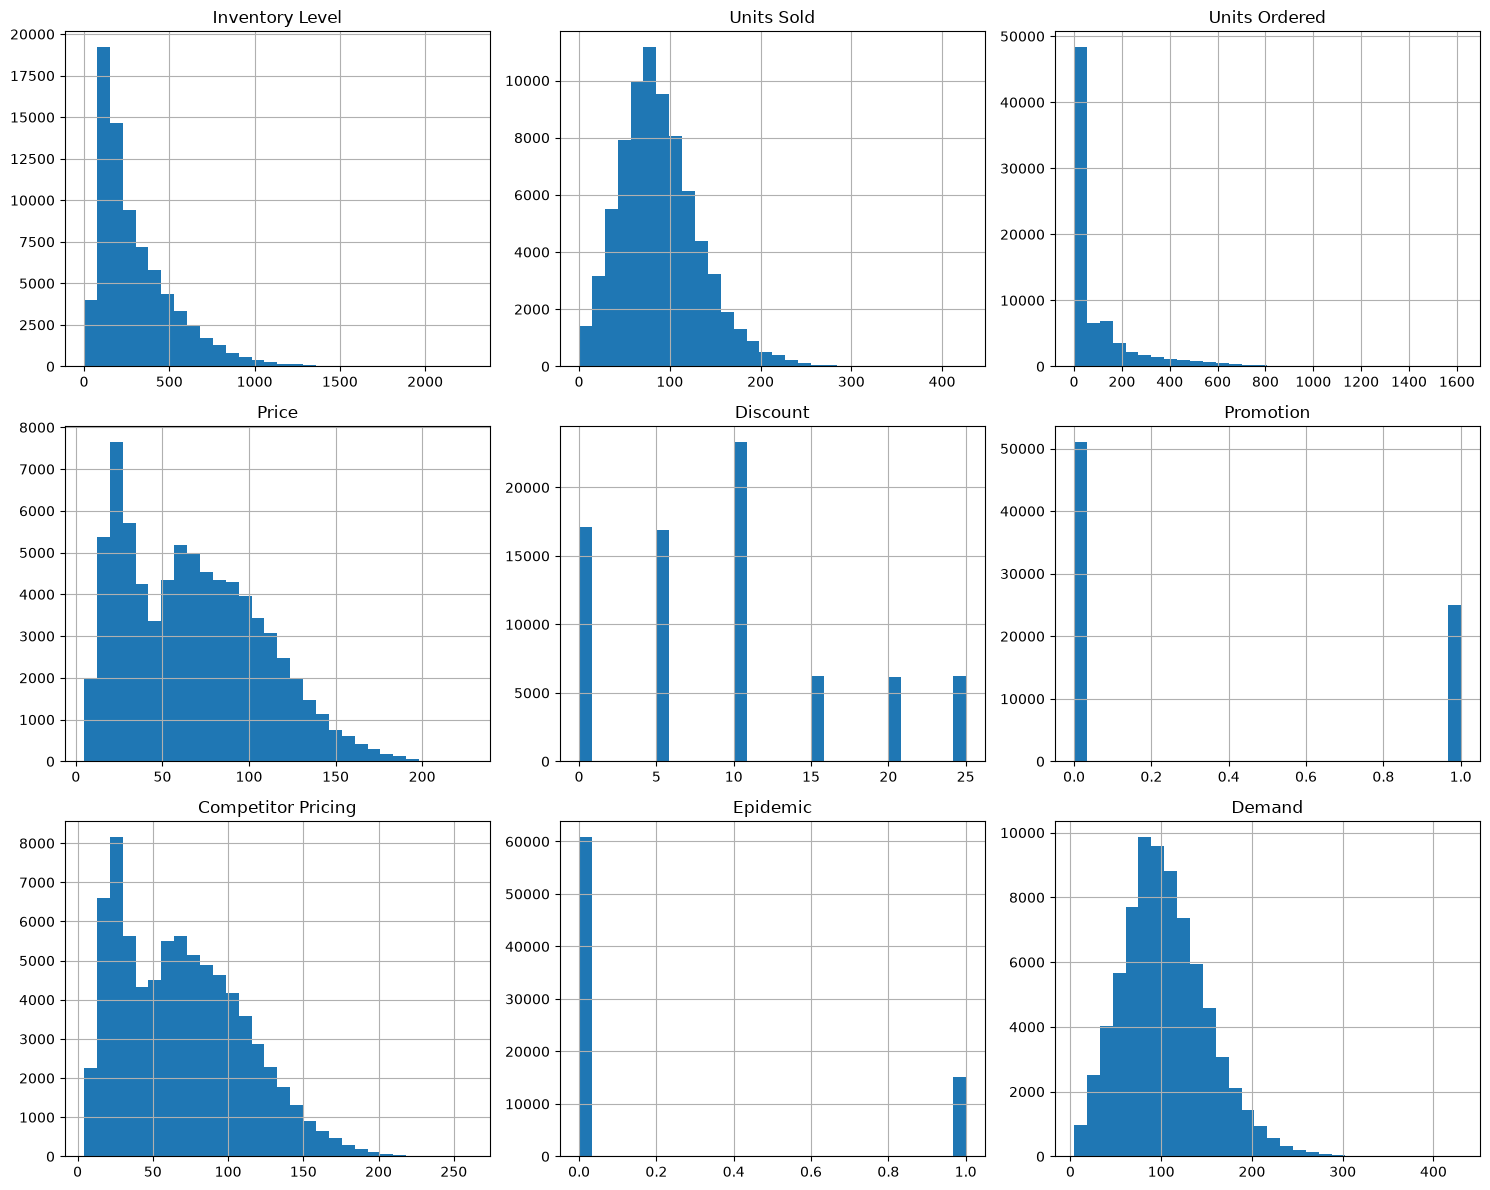

In [66]:
import matplotlib.pyplot as plt

df[numeric_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

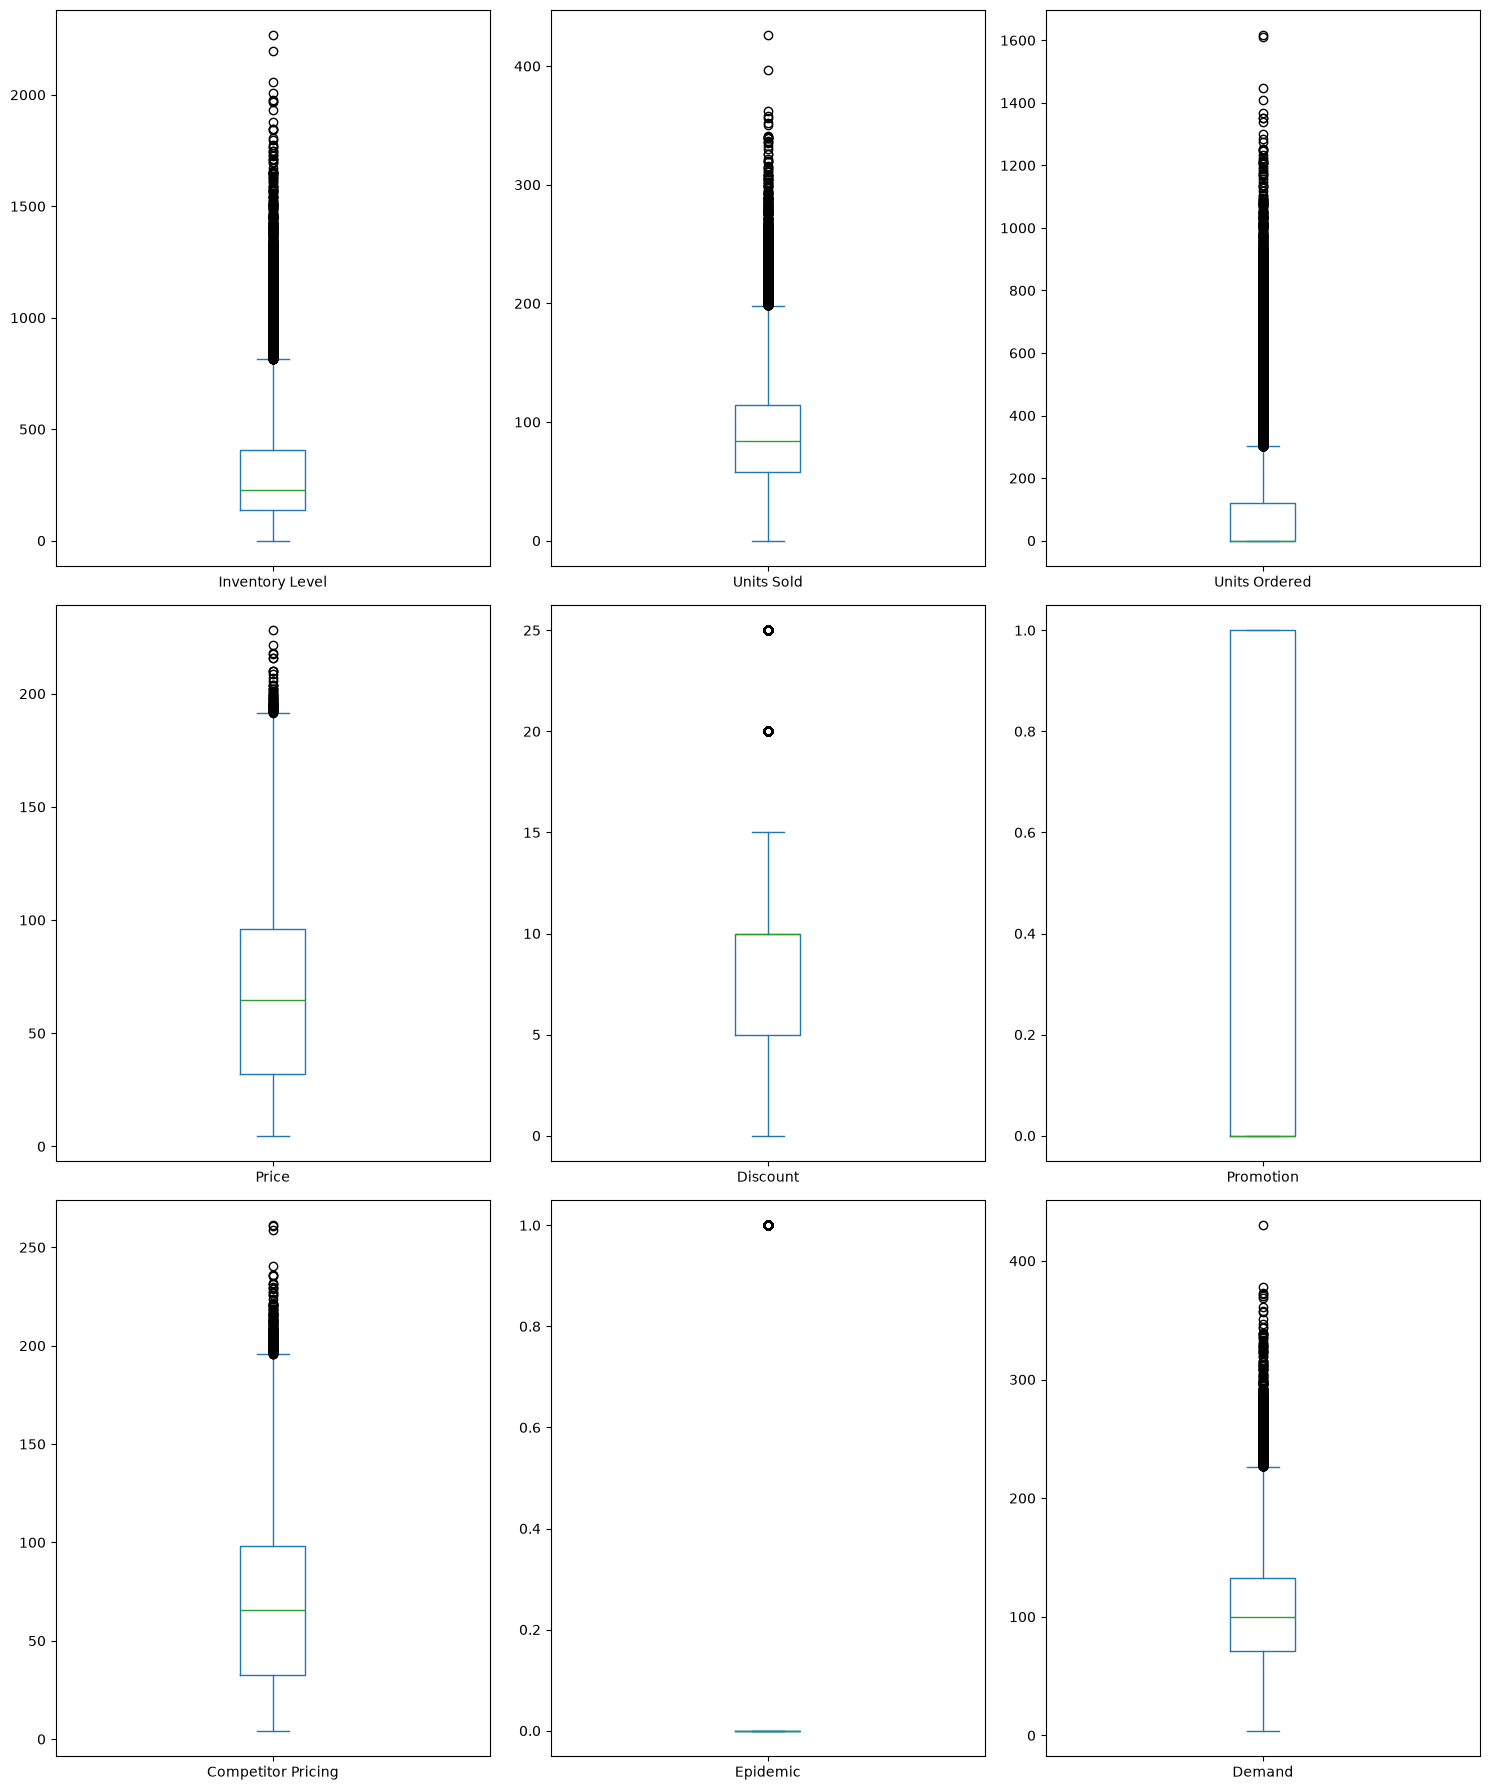

In [67]:
df[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(3,3),
    figsize=(15, 18)
)

plt.tight_layout()
plt.show()

<h1>How demands/sales vary by different dimensions</h1>

In [68]:
def demand_summary_by(column):
    return(
        df.groupby(column)
        .agg(
            demand_mean=("Demand", "mean"),
            demand_median=("Demand", "median"),
            demand_std=("Demand", "std"),
            sales_mean=("Units Sold", "mean"),
            sales_median=("Units Sold", "median"),
            observations=("Demand", "size")
        )
        .sort_values("demand_mean", ascending=False)
    )

In [69]:
demand_summary_by("Product ID")

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Product ID,,,,,,
P0009,118.506316,114.0,46.087811,99.150263,94.0,3800
P0013,116.025000,112.0,49.937341,99.136053,93.0,3800
P0004,115.396053,110.0,48.157642,99.375526,95.0,3800
P0007,115.023421,111.0,48.938656,99.923421,96.0,3800
P0002,112.066579,108.0,48.796185,94.567105,90.0,3800
P0010,111.069474,106.0,49.135104,94.026053,88.0,3800
P0001,109.591316,106.0,46.716978,93.898421,89.0,3800
P0006,107.722368,105.0,48.013768,90.681316,86.0,3800
P0005,107.520526,105.0,45.623828,92.569737,89.0,3800


In [70]:
demand_summary_by("Store ID")

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Store ID,,,,,,
S002,106.938882,103.0,45.608125,91.192500,87.0,15200
S003,106.468684,102.0,47.424239,90.500855,86.0,15200
S005,105.729276,102.0,48.269190,89.658684,85.0,15200
S001,101.814013,98.0,47.131647,86.719342,82.0,15200
S004,100.634934,96.0,45.991886,86.065197,80.0,15200


In [71]:
demand_summary_by("Category")

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Category,,,,,,
Groceries,120.976447,116.0,48.362730,102.872862,97.5,30400
Clothing,112.619737,109.0,41.022968,94.644161,91.0,12160
Electronics,97.482018,95.0,40.557859,83.041118,79.0,9120
Toys,92.606955,92.0,46.170390,78.447274,77.0,10640
Furniture,73.581140,72.0,32.336141,64.375292,61.0,13680


In [72]:
demand_summary_by("Region")

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Region,,,,,,
South,106.938882,103.0,45.608125,91.192500,87.0,15200
East,106.468684,102.0,47.424239,90.500855,86.0,15200
North,103.771645,100.0,47.743177,88.189013,83.0,30400
West,100.634934,96.0,45.991886,86.065197,80.0,15200


In [73]:
demand_summary_by("Seasonality")

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Seasonality,,,,,,
Summer,112.855380,107.0,51.930652,95.757880,90.0,18400
Autumn,103.422967,100.0,41.974885,88.462637,84.0,18200
Winter,103.406190,100.0,46.174414,87.770524,83.0,21000
Spring,97.703098,95.0,46.038644,83.463587,79.0,18400


<h1>Product</h1>

In [74]:
product_summary = demand_summary_by("Product ID")
product_summary.head(10)

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Product ID,,,,,,
P0009,118.506316,114.0,46.087811,99.150263,94.0,3800
P0013,116.025000,112.0,49.937341,99.136053,93.0,3800
P0004,115.396053,110.0,48.157642,99.375526,95.0,3800
P0007,115.023421,111.0,48.938656,99.923421,96.0,3800
P0002,112.066579,108.0,48.796185,94.567105,90.0,3800
P0010,111.069474,106.0,49.135104,94.026053,88.0,3800
P0001,109.591316,106.0,46.716978,93.898421,89.0,3800
P0006,107.722368,105.0,48.013768,90.681316,86.0,3800
P0005,107.520526,105.0,45.623828,92.569737,89.0,3800


In [75]:
product_summary.tail(10)

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Product ID,,,,,,
P0003,103.995263,101.0,46.690876,89.876579,87.0,3800
P0015,102.491579,98.0,47.096809,88.274474,83.0,3800
P0016,100.756316,97.0,46.411025,85.978421,81.0,3800
P0011,100.727895,97.0,43.578778,87.600789,82.0,3800
P0018,99.264474,94.0,45.749611,81.736053,78.0,3800
P0019,97.882632,93.0,43.761371,82.423421,79.0,3800
P0014,95.877632,91.0,44.430241,83.525526,78.0,3800
P0017,92.268421,91.0,44.254071,77.610000,75.0,3800
P0012,91.372368,87.5,41.818942,77.962105,73.0,3800


In [76]:
product_summary.sort_values(
    "observations"
).head(10)

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Product ID,,,,,,
P0009,118.506316,114.0,46.087811,99.150263,94.0,3800
P0013,116.025000,112.0,49.937341,99.136053,93.0,3800
P0004,115.396053,110.0,48.157642,99.375526,95.0,3800
P0007,115.023421,111.0,48.938656,99.923421,96.0,3800
P0002,112.066579,108.0,48.796185,94.567105,90.0,3800
P0010,111.069474,106.0,49.135104,94.026053,88.0,3800
P0001,109.591316,106.0,46.716978,93.898421,89.0,3800
P0006,107.722368,105.0,48.013768,90.681316,86.0,3800
P0005,107.520526,105.0,45.623828,92.569737,89.0,3800


<h1>Store</h1>

In [77]:
store_summary = demand_summary_by("Store ID")

store_summary

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Store ID,,,,,,
S002,106.938882,103.0,45.608125,91.192500,87.0,15200
S003,106.468684,102.0,47.424239,90.500855,86.0,15200
S005,105.729276,102.0,48.269190,89.658684,85.0,15200
S001,101.814013,98.0,47.131647,86.719342,82.0,15200
S004,100.634934,96.0,45.991886,86.065197,80.0,15200


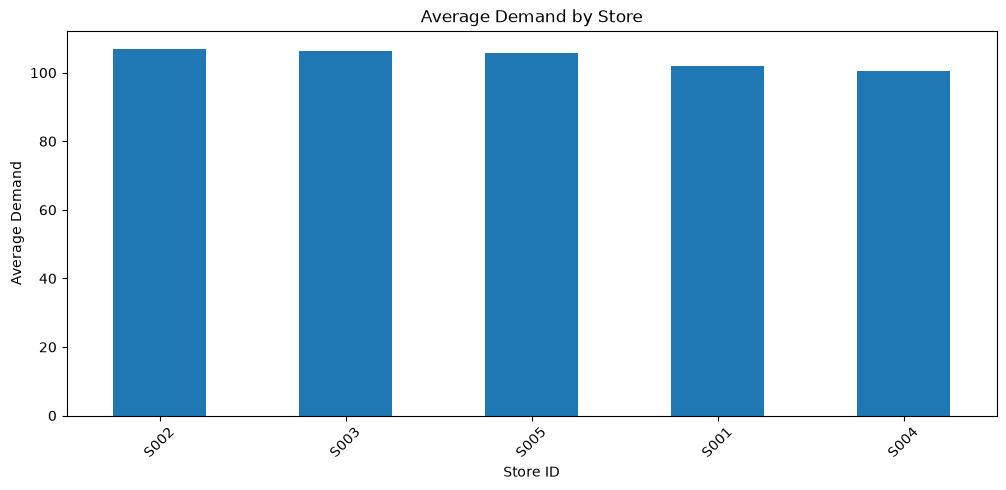

In [78]:
store_summary["demand_mean"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.ylabel("Average Demand")
plt.title("Average Demand by Store")
plt.xticks(rotation=45)
plt.show()

<h1>Category</h1>

In [79]:
category_summary = demand_summary_by("Category")
category_summary

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Category,,,,,,
Groceries,120.976447,116.0,48.362730,102.872862,97.5,30400
Clothing,112.619737,109.0,41.022968,94.644161,91.0,12160
Electronics,97.482018,95.0,40.557859,83.041118,79.0,9120
Toys,92.606955,92.0,46.170390,78.447274,77.0,10640
Furniture,73.581140,72.0,32.336141,64.375292,61.0,13680


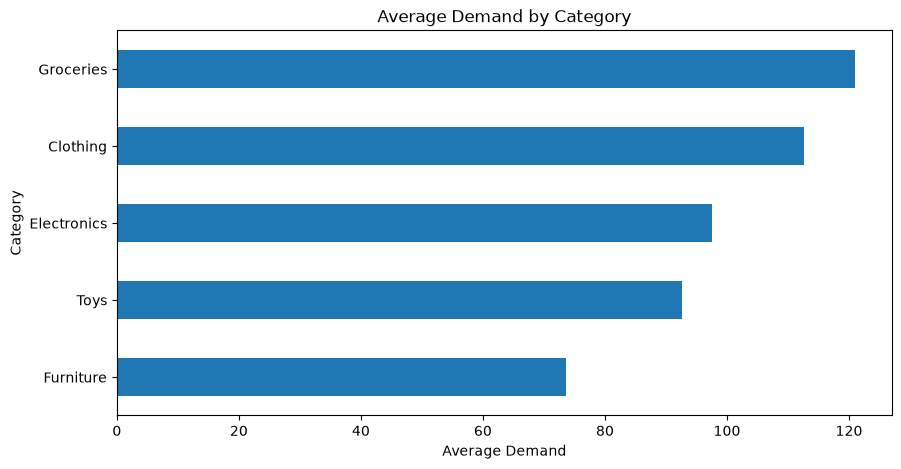

In [80]:
category_summary["demand_mean"].sort_values().plot(
    kind="barh",
    figsize=(10, 5)
)

plt.xlabel("Average Demand")
plt.title("Average Demand by Category")
plt.show()

<h1>Region</h1>

In [81]:
region_summary = demand_summary_by("Region")
region_summary

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Region,,,,,,
South,106.938882,103.0,45.608125,91.192500,87.0,15200
East,106.468684,102.0,47.424239,90.500855,86.0,15200
North,103.771645,100.0,47.743177,88.189013,83.0,30400
West,100.634934,96.0,45.991886,86.065197,80.0,15200


<h1>Seasonality</h1>

In [82]:
seasonality_summary = demand_summary_by("Seasonality")

seasonality_summary

,demand_mean,demand_median,demand_std,sales_mean,sales_median,observations
Seasonality,,,,,,
Summer,112.855380,107.0,51.930652,95.757880,90.0,18400
Autumn,103.422967,100.0,41.974885,88.462637,84.0,18200
Winter,103.406190,100.0,46.174414,87.770524,83.0,21000
Spring,97.703098,95.0,46.038644,83.463587,79.0,18400


<h1>Promotion</h1>

In [83]:
df.groupby("Promotion").agg(
    demand_mean=("Demand", "mean"),
    demand_median=("Demand", "median"),
    sales_mean=("Units Sold", "mean"),
    observations=("Demand", "size")
)

,demand_mean,demand_median,sales_mean,observations
Promotion,,,,
0,95.026843,92.0,81.833314,51000
1,123.269400,120.0,103.095080,25000


<h1>Weather</h1>

In [84]:
df.groupby("Weather Condition").agg(
    demand_mean=("Demand", "mean"),
    demand_median=("Demand", "median"),
    sales_mean=("Units Sold", "mean"),
    observations=("Demand", "size")
).sort_values(
    "demand_mean",
    ascending=False
)

,demand_mean,demand_median,sales_mean,observations
Weather Condition,,,,
Sunny,115.167189,111.0,97.027937,22980
Cloudy,105.404064,102.0,89.625369,24360
Rainy,95.106743,92.0,81.972286,17500
Snowy,94.045789,91.0,80.948477,11160


<h1>Temporal trend and Seasonality</h1>

In [85]:
df["Date"] = pd.to_datetime(df["Date"])

In [86]:
print("Start:", df["Date"].min())
print("End:", df["Date"].max())
print("Unique dates:", df["Date"].nunique())

Start: 2022-01-01 00:00:00
End: 2024-01-30 00:00:00
Unique dates: 760


<h1>Daily Demand</h1>

In [87]:
daily_demand = (
    df.groupby("Date")
    .agg(
        total_demand=("Demand", "sum"),
        total_sales=("Units Sold", "sum")
    )
    .sort_index()
)

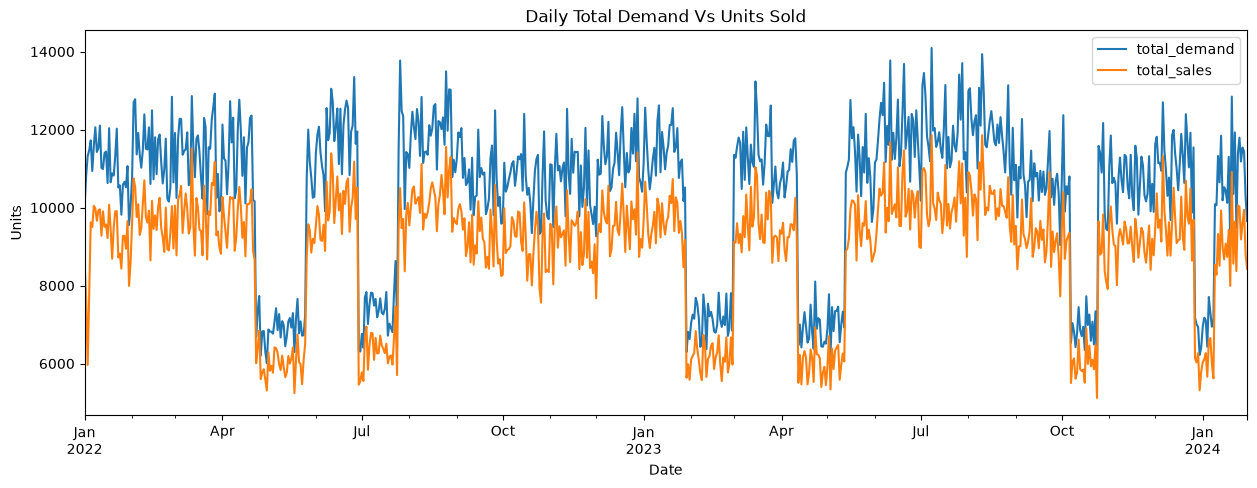

In [88]:
daily_demand.plot(
    figsize=(15,5)
)

plt.title("Daily Total Demand Vs Units Sold")
plt.xlabel("Date")
plt.ylabel("Units")
plt.show()

<h1>Weekly Pattern</h1>

In [89]:
df["DayOfWeek"] = df["Date"].dt.day_name()

In [90]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_pattern = (
    df.groupby("DayOfWeek")["Demand"]
    .agg(["mean", "median", "std", "count"])
    .reindex(day_order)
)

weekly_pattern

,mean,median,std,count
DayOfWeek,,,,
Monday,103.423303,99.0,46.479319,10900
Tuesday,103.665229,99.0,46.889936,10900
Wednesday,105.192037,101.0,47.908105,10800
Thursday,104.408333,100.0,46.662997,10800
Friday,104.394444,101.0,46.288416,10800
Saturday,104.484037,100.0,47.409272,10900
Sunday,104.662294,101.0,47.085348,10900


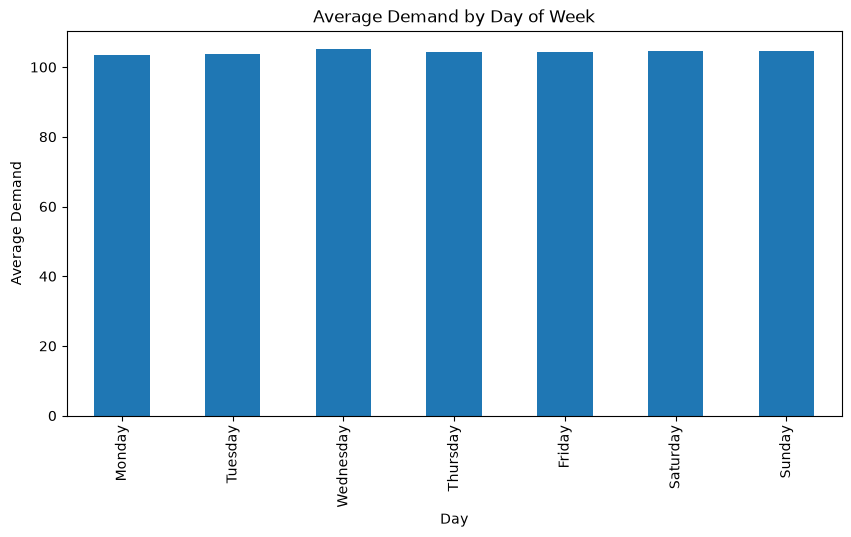

In [91]:
weekly_pattern["mean"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Demand by Day of Week")
plt.ylabel("Average Demand")
plt.xlabel("Day")
plt.show()

<h1>Monthly Pattern</h1>

In [92]:
df["Month"] = df["Date"].dt.month

monthly_pattern = (
    df.groupby("Month")["Demand"]
    .agg(["mean", "median", "std", "count"])
)

monthly_pattern

,mean,median,std,count
Month,,,,
1,106.040000,103.0,44.699476,9200
2,92.882500,89.0,48.117713,5600
3,113.613871,109.0,43.529531,6200
4,92.816667,89.0,46.147069,6000
5,86.521129,82.0,43.976627,6200
6,117.346000,111.0,51.258910,6000
7,101.561613,96.0,52.552334,6200
8,119.803387,113.0,50.044154,6200
9,107.431500,103.0,40.640041,6000


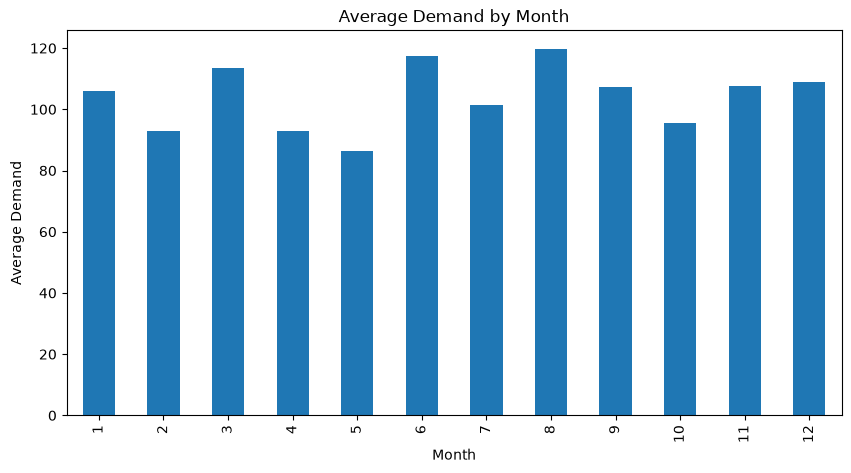

In [93]:
monthly_pattern["mean"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Demand by Month")
plt.ylabel("Average Demand")
plt.xlabel("Month")
plt.show()

<h1>Rolling demand</h1>

In [94]:
daily_demand["7_day_avg"] = (
    daily_demand["total_demand"]
    .rolling(7)
    .mean()
)

daily_demand["30_day_avg"] = (
    daily_demand["total_demand"]
    .rolling(30)
    .mean()
)

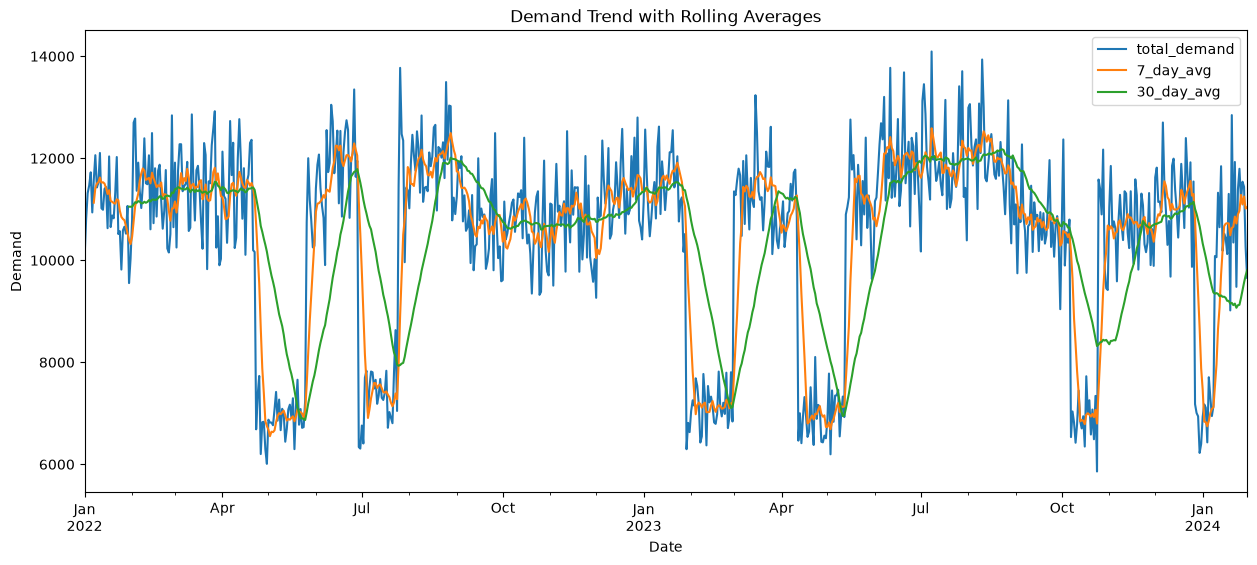

In [95]:
daily_demand[
    ["total_demand", "7_day_avg", "30_day_avg"]
].plot(figsize=(15, 6))

plt.title("Demand Trend with Rolling Averages")
plt.ylabel("Demand")
plt.show()

<h1>Demand Vs Units Sold</h1>

In [96]:
df["Demand_minus_Sales"] = (
    df["Demand"] - df["Units Sold"]
)

In [97]:
df["Demand_minus_Sales"].describe()

count    76000.000000
mean        15.489842
std         26.404353
min        -68.000000
25%         -2.000000
50%         11.000000
75%         27.000000
max        316.000000
Name: Demand_minus_Sales, dtype: float64

In [98]:
(df["Demand"] == df["Units Sold"]).mean()

np.float64(0.020526315789473684)

In [99]:
df["Demand_minus_Sales"].value_counts().head(20)

Demand_minus_Sales
 1     1573
 0     1560
-1     1543
 4     1535
 2     1517
 3     1498
 6     1478
 8     1466
-2     1463
 7     1462
 5     1449
 9     1443
-3     1422
 10    1422
-4     1374
 12    1370
-5     1363
 13    1337
 11    1328
 14    1306
Name: count, dtype: int64

In [100]:
df[
    df["Demand"] > df["Units Sold"]
][
    [
        "Inventory Level",
        "Units Sold",
        "Units Ordered",
        "Demand"
    ]
].describe()

,Inventory Level,Units Sold,Units Ordered,Demand
count,53440.000000,53440.000000,53440.000000,53440.00000
mean,287.706044,80.997979,93.004117,106.97820
std,225.157703,38.844811,161.740702,47.58144
min,0.000000,0.000000,0.000000,4.00000
25%,126.000000,54.000000,0.000000,73.00000
50%,211.000000,77.000000,0.000000,103.00000
75%,391.000000,104.000000,131.000000,136.00000
max,2267.000000,339.000000,1609.000000,430.00000
